# Notebook magic

## Show us the buildings!!

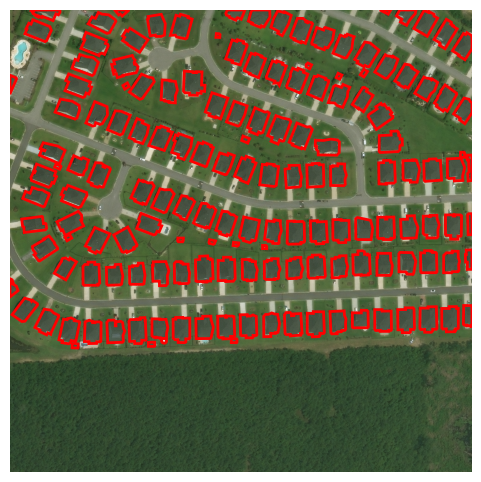

In [63]:
from PIL import Image
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.patches import Polygon
import os


# Path to your TIF image file
TRAINING1_DIRS = ('./geotiffs/tier1/images/', './geotiffs/tier1/labels/')
TRAINING3_DIRS = ('./geotiffs/tier3/images/', './geotiffs/tier3/labels/')
VAL_DIRS = ('./geotiffs/test/images/', './geotiffs/test/labels/')
TEST_DIRS = ('./geotiffs/hold/images/', './geotiffs/hold/labels/')

PARENT_PATH = './dataset/'
HOLDOUT_PATH = f'{PARENT_PATH}holdout/'

TRAIN_DEST = (f'{PARENT_PATH}images/',f'{PARENT_PATH}masks/')
VAL_DEST = (f'{PARENT_PATH}images_val/',f'{PARENT_PATH}masks_val/')
TEST_DEST = (f'{HOLDOUT_PATH}images_test/',f'{HOLDOUT_PATH}masks_test/')



# make directories if they don't exist
for dest in (TRAIN_DEST, VAL_DEST, TEST_DEST):
    png_path, mask_path = dest
    if not os.path.exists(png_path):
        os.makedirs(png_path)
    if not os.path.exists(mask_path):
        os.makedirs(mask_path)


def get_polygon_coords(name, size, dirs):
    """
    Returns a nested list of pixel coordinates associated with the buildings in the given image.
    """
    dir = dirs[1]
    with open(f'{dir}{name}.json', 'r') as f:
        feats = json.loads(f.read())
        polygons = []
        for coord_list in feats['features']['xy']:
            polygon = []
            for coord_pair in coord_list['wkt'][10:-2].split(', '):
                pair = coord_pair.split(' ')
                parsed_pair = (float(pair[0]) * (size[0]/1024), float(pair[1]) * (size[0]/1024))
                polygon.append(parsed_pair)
            polygons.append(polygon)
        return polygons


def draw_img(name, dirs):
    """
    Draws the image with overlaid polygons.
    """
    dir = dirs[0]
    with rasterio.open(f'{dir}{name}.tif') as dataset:
        # Multi-band (e.g., RGB) image, read first three bands
        img = dataset.read([1, 2, 3])  # Read RGB bands
        img = np.transpose(img, (1, 2, 0))  # Reorder to (height, width, channels)
        _, ax = plt.subplots(figsize=(6,6))
        poly_coords_list = get_polygon_coords(name, (1024,1024), dirs)
        cmap = None
        ax.imshow(img, cmap=cmap)

        # Create and add the polygon
        for polygon_coords in poly_coords_list:
            poly = Polygon(polygon_coords, closed=True, fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(poly)

        # Set plot limits to match image dimensions
        ax.set_xlim(0, dataset.width)
        ax.set_ylim(dataset.height, 0)  # Invert Y-axis to match image coordinates

        # Hide axes for cleaner display
        ax.axis('off')

        # Show the plot
        plt.show()

#dir = VAL_DIRS
#name = os.listdir(dir[0])[25][:-4]
dir = TEST_DIRS
florence14 = 'hurricane-florence_00000014_pre_disaster' 
draw_img(florence14, dir)

## Turn Tiffs into 512x512 pngs

In [ ]:
from shapely.geometry import Polygon, mapping
from rasterio.features import rasterize
from tqdm import tqdm


def save_as_png(name, size, dirs, to_dir):
    from_dir = dirs[0]
    with rasterio.open(f'{from_dir}{name}.tif') as dataset:
        # Multi-band (e.g., RGB) image, read first three bands
        img = dataset.read([1, 2, 3])  # Read RGB bands
        img = np.transpose(img, (1, 2, 0))  # Reorder to (height, width, channels)
        return (Image.fromarray(img.astype(np.uint8))
            .resize(size)
            .save(f'{to_dir}{name}.png', 'PNG'))


def create_binary_mask(polygon_coords, img_shape, name, to_dir):
    polygons = [Polygon(coords) for coords in polygon_coords]
    """Rasterize polygons to binary PNG mask (0=background, 1=building)."""
    mask = np.zeros(img_shape[:2], dtype=np.uint8)  # 512x512

    # Rasterize all polygons (1 for building)
    shapes = [(mapping(poly), 1) for poly in polygons] # use mapping with 1 for training, or 255 for visibility
    mask = rasterize(shapes, out_shape=img_shape[:2], fill=0, default_value=1)
    Image.fromarray(mask.astype(np.uint8)).save(f'{to_dir}{name}.png', 'PNG')

size = (512, 512)

for (dirs, dests) in [
       # (TRAINING1_DIRS, TRAIN_DEST), 
        #(TRAINING3_DIRS, TRAIN_DEST),
        (VAL_DIRS, VAL_DEST),
        (TEST_DIRS, TEST_DEST)
        ]:
    png_path, mask_path = dests
    names = list(map(lambda x: x[:-4], os.listdir(dirs[0])))

    already_pngified = set(os.listdir(png_path))
    already_masked = set(os.listdir(mask_path))
    for name in tqdm(names):
        if 'pre' in name:
            if f'{name}.png' not in already_pngified or f'{name}.png' not in already_masked:
                coords = get_polygon_coords(name, size, dirs)
                create_binary_mask(coords, size, name, mask_path)
                save_as_png(name, size, dirs, png_path)




100%|██████████| 1866/1866 [04:40<00:00,  6.66it/s]


: 

## Make a .txt file with the names of the validation set

In [ ]:
def make_split_file():
    names_val = list(map(lambda x: x[:-4], os.listdir(VAL_DIRS[0])))
    with open(VALIDATION_FILE, 'w') as f:
        for name in names_val:
            if 'pre' in name:
                f.write(f'{name}\n')

make_split_file()


## Find the ratio between buildings and background

In [25]:
from tqdm import tqdm
names_train = os.listdir(TRAIN_DEST[1])
buildings = 0
background = 0
i = 0
for name in (pbar := tqdm(names_train)): 
    pic = Image.open(TRAIN_DEST[1] + name)
    arr = np.array(pic.getdata(), dtype=np.uint64)
     #np.unique(arr, return_counts=True)
    summ = np.sum(arr) 
    buildings += summ 
    background += arr.size - summ 
    if i % 100 == 0: 
        pbar.set_description(f'Buildings: {buildings}, Background: {background}, Ratio: {buildings/background}')
    i += 1 
print(f'Buildings: {buildings}, Background: {background}, Ratio: {buildings/background}')

Buildings: 6256242.0, Background: 125077902.0, Ratio: 0.05001876350628267:   7%|▋         | 600/9168 [00:08<02:01, 70.57it/s]


KeyboardInterrupt: 

## Find the image in the test set with the most buildings:

In [45]:
from tqdm import tqdm
names_test = os.listdir(TEST_DIRS[1])
max_buildings = 0
best_image = ''
i = 0
for name in names_test:
    if 'post' in name:
        continue 
    pic = Image.open(TEST_DEST[1] + name[:-4] + "png")
    arr = np.array(pic.getdata())
    summ = np.sum(arr) 
    if summ > max_buildings:
        max_buildings = summ
        best_image = name
    if i % 100 == 0:
        print(best_image) 
        #pbar.set_description(f'best: {best_image}, pixels: {max_buildings}')
    i += 1 
print(f'Image with most buildings: {best_image}, pixels: {max_buildings/(512*512)}')
#9, 124, 203, 431, 565 
#palu-tsunami_00000095_pre_disaster.json

guatemala-volcano_00000004_pre_disaster.json
hurricane-florence_00000014_pre_disaster.json
hurricane-harvey_00000004_pre_disaster.json
hurricane-harvey_00000409_pre_disaster.json
hurricane-harvey_00000409_pre_disaster.json
mexico-earthquake_00000056_pre_disaster.json
palu-tsunami_00000095_pre_disaster.json
palu-tsunami_00000095_pre_disaster.json
palu-tsunami_00000095_pre_disaster.json
palu-tsunami_00000095_pre_disaster.json
Image with most buildings: palu-tsunami_00000095_pre_disaster.json, pixels: 0.5937347412109375


## generate visible mask

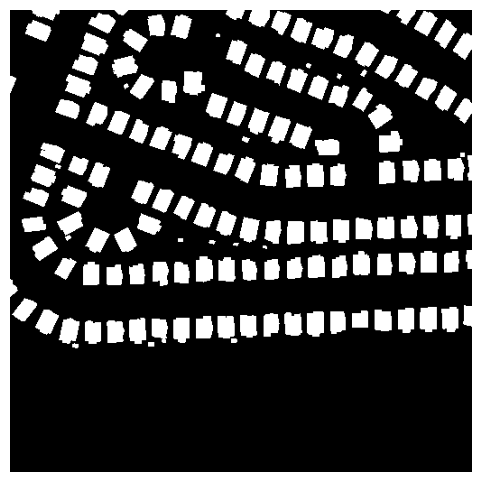

In [62]:
def visualize_binary_mask(path_in):
    """
    Given a 512x512 PNG of 1s and 0s, produce a visible image where
    0s are black and 1s are white.

    Args:
        path_in (str): Path to input PNG file (binary mask).
        path_out (str): Path to save the visualized image.
    """
    # Load image and convert to grayscale
    img = Image.open(path_in).convert('L')
    arr = np.array(img)

    # Ensure it's binary: anything > 0 becomes 1
    binary = (arr > 0).astype(np.uint8)

    # Scale 0→0 and 1→255 for visibility
    visual = (binary * 255).astype(np.uint8)

    # Save as visible black/white image
    plt.figure(figsize=(6,6))
    plt.imshow(visual, cmap='gray')
    plt.axis('off')
    plt.show()


visualize_binary_mask(f'{TEST_DEST[1]}{florence14}.png')